In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [9]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
df.drop(columns=["RowNumber",
                 "CustomerId",
                 "Surname"],
                 inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns= ["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,
                                                    test_size=0.2)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
import tensorflow


In [16]:
from keras.models import Sequential
from keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(11, activation="sigmoid"))
model.add(Dense(10, activation="sigmoid"))
model.add(Dense(1, activation="sigmoid"))

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263 (1.03 KB)

 Trainable params: 263 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7387 - loss: 0.5721 - val_accuracy: 0.7987 - val_loss: 0.5000
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4990 - val_accuracy: 0.7987 - val_loss: 0.4830
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4851 - val_accuracy: 0.7987 - val_loss: 0.4659
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4688 - val_accuracy: 0.7987 - val_loss: 0.4477
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7936 - loss: 0.4532 - val_accuracy: 0.8025 - val_loss: 0.4333
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.4418 - val_accuracy: 0.8219 - val_loss: 0.4257
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8072 - loss: 0.4360 - val_accuracy: 0.8206 - val_loss: 0.4204
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8077 - loss: 0.4326 - val_accu

In [20]:
model.layers[1].get_weights()

[array([[ 0.9105965 ,  0.88298804,  0.5024909 , -0.70409054,  0.48322886,
         -0.7304566 ,  0.54855573, -0.6525098 ,  0.72857684, -0.85131186],
        [ 0.5123467 ,  0.06490123,  0.13242865, -0.11966079,  0.6617717 ,
         -0.91364807,  1.2640347 , -0.8162673 ,  0.22632016, -0.7964239 ],
        [ 0.9059909 ,  1.2672929 ,  1.5742532 , -0.78838116,  0.79877406,
         -0.9756042 ,  0.8889483 , -0.7428966 ,  0.95111984, -0.70287913],
        [ 0.40122804,  0.19823682,  0.00998094, -0.8471949 ,  0.86288106,
         -0.4175998 ,  0.61446124, -0.6883464 ,  0.35147938, -0.9793008 ],
        [-1.67418   , -1.3241351 , -1.4286183 ,  1.017243  , -1.3347614 ,
          0.9853192 , -1.694345  ,  1.385619  , -1.567373  ,  1.4992466 ],
        [ 0.38212633,  0.6829196 ,  0.26841924, -0.4814697 ,  0.45402515,
         -0.64927775,  1.0107067 , -0.59621555,  1.1003934 , -0.19069442],
        [ 0.40557882,  0.9712066 ,  0.3000056 , -0.49443233,  0.49549696,
         -1.2031426 ,  0.6104960

In [21]:
model.layers[0].get_weights()

[array([[-0.23611578,  0.01241497,  0.41722918,  0.01401253,  0.01626213,
          0.00842405, -0.02014801, -0.16406876,  0.1890968 , -0.35476595,
          0.19128819],
        [ 0.6426078 , -1.9007401 , -0.0923227 , -1.725476  , -0.96041685,
         -1.3721676 ,  0.03835031,  0.2003895 , -1.6461385 ,  1.3410966 ,
         -0.5948728 ],
        [-0.29145578,  0.643024  ,  0.16684075, -0.11081906, -0.03914879,
         -0.08223396,  0.19962491,  0.1183844 ,  0.24391814,  0.42373183,
          0.03787709],
        [-0.1286174 ,  0.36222592, -2.1512861 , -0.52665335, -0.24335946,
          0.04128782,  0.21019672, -0.1509287 ,  0.3241642 , -0.44370905,
         -0.79965633],
        [-1.2053207 , -0.88901895, -1.6913087 , -0.96533614, -3.3453496 ,
         -0.80399096, -1.0985751 , -0.5398451 , -0.8729307 ,  0.8299136 ,
         -2.778895  ],
        [-0.28379053,  0.3451102 ,  0.07150191,  0.0121914 , -0.22378421,
         -0.11323424,  0.11426614,  0.22526608,  0.47581577,  0.4138236

In [22]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step


In [23]:
y_pred = np.where(y_log>0.5, 1, 0)

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,
               y_pred)

0.8655

In [25]:
import matplotlib.pyplot as plt

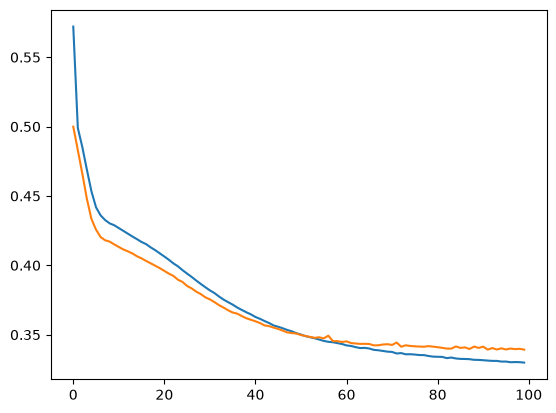

In [26]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [27]:
history.history

{'accuracy': [0.7387499809265137,
  0.7934374809265137,
  0.7934374809265137,
  0.7934374809265137,
  0.7935937643051147,
  0.7975000143051147,
  0.8071874976158142,
  0.8076562285423279,
  0.8090624809265137,
  0.8098437786102295,
  0.8112499713897705,
  0.8148437738418579,
  0.8181250095367432,
  0.8178125023841858,
  0.8209375143051147,
  0.821093738079071,
  0.8246874809265137,
  0.8278124928474426,
  0.8282812237739563,
  0.8295312523841858,
  0.8318750262260437,
  0.8337500095367432,
  0.8353124856948853,
  0.8365625143051147,
  0.836718738079071,
  0.8376562595367432,
  0.8399999737739563,
  0.8409374952316284,
  0.8414062261581421,
  0.8434374928474426,
  0.8434374928474426,
  0.84375,
  0.8453124761581421,
  0.846875011920929,
  0.8485937714576721,
  0.8495312333106995,
  0.8495312333106995,
  0.8521875143051147,
  0.8525000214576721,
  0.8548437356948853,
  0.8529687523841858,
  0.8548437356948853,
  0.854687511920929,
  0.8560937643051147,
  0.856249988079071,
  0.8585937619